## Predicción del precio en Melbourne

Autor: Eloy García Martínez

### Librerías necesarias

In [10]:
%pip install kagglehub[pandas-datasets]

Note: you may need to restart the kernel to use updated packages.


In [1]:
import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import TargetEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

from sklearn.model_selection import train_test_split 

### Importar el Dataset

In [15]:
#falla por haber valores vacios seguramente
file_path = "Melbourne_housing_FULL.csv"
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "anthonypino/melbourne-housing-market",
  file_path,
)

df.head()

C:\Users\eloy.garciamartinez\AppData\Local\Temp\ipykernel_3024\3323183699.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.50,"3,067.00",...,1.00,1.00,126.00,NaN,NaN,Yarra City Council,-37.80,145.00,Northern Metropolitan,"4,019.00"
1,Abbotsford,85 Turner St,2,h,"1,480,000.00",S,Biggin,3/12/2016,2.50,"3,067.00",...,1.00,1.00,202.00,NaN,NaN,Yarra City Council,-37.80,145.00,Northern Metropolitan,"4,019.00"
2,Abbotsford,25 Bloomburg St,2,h,"1,035,000.00",S,Biggin,4/02/2016,2.50,"3,067.00",...,1.00,0.00,156.00,79.00,"1,900.00",Yarra City Council,-37.81,144.99,Northern Metropolitan,"4,019.00"
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.50,"3,067.00",...,2.00,1.00,0.00,NaN,NaN,Yarra City Council,-37.81,145.01,Northern Metropolitan,"4,019.00"
4,Abbotsford,5 Charles St,3,h,"1,465,000.00",SP,Biggin,4/03/2017,2.50,"3,067.00",...,2.00,0.00,134.00,150.00,"1,900.00",Yarra City Council,-37.81,144.99,Northern Metropolitan,"4,019.00"


In [43]:
df = pd.read_csv("Melbourne_housing_FULL.csv")

df.head(10)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.50,"3,067.00",...,1.00,1.00,126.00,NaN,NaN,Yarra City Council,-37.80,145.00,Northern Metropolitan,"4,019.00"
1,Abbotsford,85 Turner St,2,h,"1,480,000.00",S,Biggin,3/12/2016,2.50,"3,067.00",...,1.00,1.00,202.00,NaN,NaN,Yarra City Council,-37.80,145.00,Northern Metropolitan,"4,019.00"
2,Abbotsford,25 Bloomburg St,2,h,"1,035,000.00",S,Biggin,4/02/2016,2.50,"3,067.00",...,1.00,0.00,156.00,79.00,"1,900.00",Yarra City Council,-37.81,144.99,Northern Metropolitan,"4,019.00"
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.50,"3,067.00",...,2.00,1.00,0.00,NaN,NaN,Yarra City Council,-37.81,145.01,Northern Metropolitan,"4,019.00"
4,Abbotsford,5 Charles St,3,h,"1,465,000.00",SP,Biggin,4/03/2017,2.50,"3,067.00",...,2.00,0.00,134.00,150.00,"1,900.00",Yarra City Council,-37.81,144.99,Northern Metropolitan,"4,019.00"
5,Abbotsford,40 Federation La,3,h,"850,000.00",PI,Biggin,4/03/2017,2.50,"3,067.00",...,2.00,1.00,94.00,NaN,NaN,Yarra City Council,-37.80,145.00,Northern Metropolitan,"4,019.00"
6,Abbotsford,55a Park St,4,h,"1,600,000.00",VB,Nelson,4/06/2016,2.50,"3,067.00",...,1.00,2.00,120.00,142.00,"2,014.00",Yarra City Council,-37.81,144.99,Northern Metropolitan,"4,019.00"
7,Abbotsford,16 Maugie St,4,h,NaN,SN,Nelson,6/08/2016,2.50,"3,067.00",...,2.00,2.00,400.00,220.00,"2,006.00",Yarra City Council,-37.80,145.00,Northern Metropolitan,"4,019.00"
8,Abbotsford,53 Turner St,2,h,NaN,S,Biggin,6/08/2016,2.50,"3,067.00",...,1.00,2.00,201.00,NaN,"1,900.00",Yarra City Council,-37.80,145.00,Northern Metropolitan,"4,019.00"
9,Abbotsford,99 Turner St,2,h,NaN,S,Collins,6/08/2016,2.50,"3,067.00",...,2.00,1.00,202.00,NaN,"1,900.00",Yarra City Council,-37.80,145.00,Northern Metropolitan,"4,019.00"


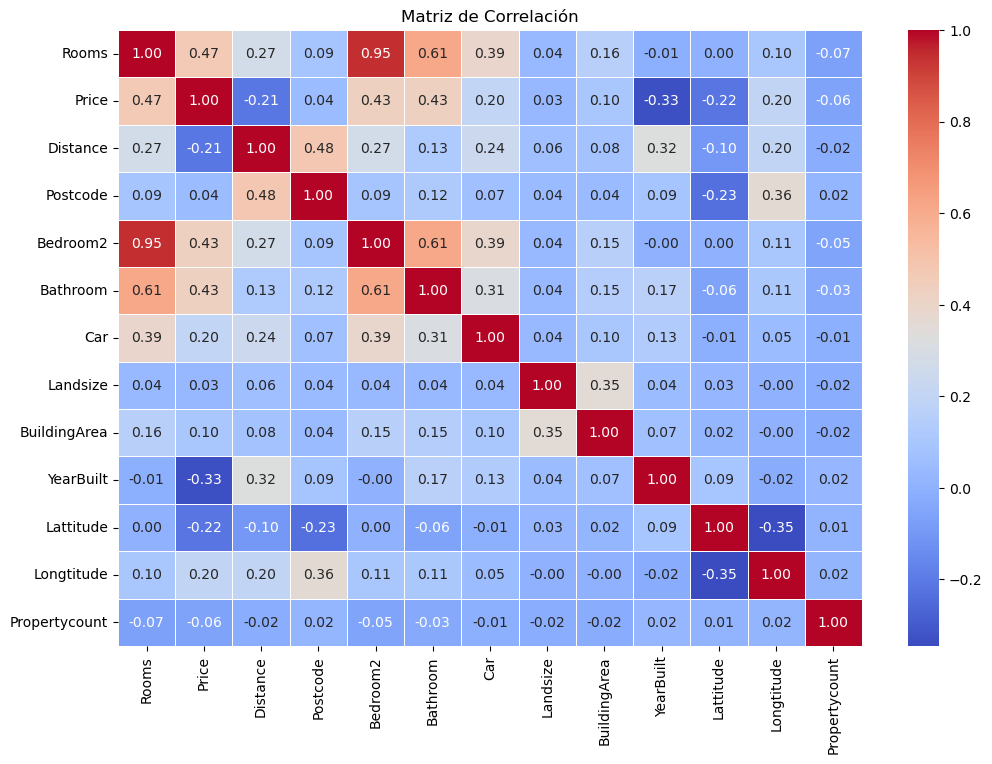

In [44]:
#solo columnas numéricas
numeric_df = df.select_dtypes(include=['float64', 'int64'])

corr_matrix = numeric_df.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de Correlación')
plt.show()

### Preprocesado de datos

In [45]:
#nos quedamos con el 98% central de los datos de precio, asi reduccimos el sesgo ya que hay casas con precios muy desproporcionados
price_inferior = df['Price'].quantile(0.01)  #1%de las casas mas baratas, quantile ordena de menor a mayor
price_superior = df['Price'].quantile(0.99) #el último 1% de las casas mas caras
df = df[(df['Price'] > price_inferior) & (df['Price'] < price_superior)]

#eliminamos columnas: price porque es el target, address porque son todos  diferentes y es ruido igual que lattitude y longtitude, date porque al ser texto el modelo
#no interpreta fechas asi, el SellerG información irrelevante aunque haya vendedores que puedan vender mas caro no nos aporta info relevante al igual que el metodo de venta
X = df.drop(['Price', 'Address', 'SellerG', 'Postcode', 'Lattitude', 'Longtitude', 'CouncilArea', 'Method', 'Propertycount', 'Date'], axis=1)
y = df['Price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print({X_train.shape}, {X_test.shape}, {y_train.shape}, {y_test.shape})

{(21349, 11)} {(5338, 11)} {(21349,)} {(5338,)}


In [46]:
#eliminamos los valores nulos en la etiqueta
y_train = y_train.dropna()
X_train = X_train.loc[y_train.index]
y_test = y_test.dropna()
X_test = X_test.loc[y_test.index]

categorical_cols = X_train.select_dtypes(include=['object']).columns.tolist()
numeric_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()

#creamos preprocessor ColumnTransformer con pipelines porque el df es mixto
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            #('encoder', OneHotEncoder(handle_unknown='infrequent_if_exist', max_categories=15))  #solo crea 15 columnas de categorias y el resto a una columna 'infrequent'
            ('encoder', TargetEncoder(target_type='continuous')) #mejor que one-hot al haber muchas categorias, cambia categorias por un valor medio basado en el target (price)
        ]), categorical_cols),
        
        # Camino para números (Imputar + ESCALAR)
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())  # Ahora todos los números tendrán media 0 y desv. típica 1, esto no es necesario para arboles de decision que son inmunes a escalados, no les importa la medida de los datos
    ]), numeric_cols)
    ])

In [47]:
model = Pipeline([
    ('prep', preprocessor),
    ('estimator', RandomForestRegressor(random_state=42))
])

model.fit(X_train, y_train)

,steps,"[('prep', ...), ('estimator', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Tuning de hiperparametros

In [48]:
param_grid = {
    'estimator__n_estimators': [50, 100, 200],
    'estimator__max_depth': [5, 7, 10, None],
    'estimator__min_samples_split': [5, 10, 15],
    'estimator__min_samples_leaf': [2, 4, 6] 
}

grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, n_jobs=-1)
grid_search.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'estimator__max_depth': [5, 7, ...], 'estimator__min_samples_leaf': [2, 4, ...], 'estimator__min_samples_split': [5, 10, ...], 'estimator__n_estimators': [50, 100, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('cat', ...), ('num', ...)]"


### Predicciones y conclusiones

In [49]:
y_pred = grid_search.predict(X_test)

score = grid_search.score(X_test, y_test)
print(score)

0.8046140378332077


In [50]:
#rmse con validacion cruzada max. 5 particiones
cv_scores = cross_val_score(estimator=grid_search.best_estimator_, X=X_train, y=y_train, 
                            scoring='neg_root_mean_squared_error', cv=5)

rmse = -cv_scores.mean()
print(f"RMSE: {rmse:,.2f}")

RMSE: 245,433.45


In [52]:
df_test_con_pred = df.loc[X_test.index].copy()
df_test_con_pred['Predicted_price'] = y_pred
pd.options.display.float_format = '{:,.2f}'.format
df_test_con_pred.sort_values(by='Price' ,ascending=True).head(20)

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Predicted_price
25478,Aberfeldie,2/37 St Kinnord St,1,u,"312,000.00",SP,Brad,28/10/2017,7.50,"3,040.00",...,NaN,NaN,NaN,NaN,Moonee Valley City Council,NaN,NaN,Western Metropolitan,"1,543.00","386,176.58"
15119,Melton South,19 Kingsford Av,3,h,"315,000.00",SP,Ray,3/06/2017,29.80,"3,338.00",...,NaN,NaN,NaN,NaN,Melton City Council,NaN,NaN,Western Victoria,"4,718.00","391,701.86"
30266,Dandenong North,1/1 Rhoden Ct,2,u,"315,000.00",PI,Harcourts,9/12/2017,24.70,"3,175.00",...,1.00,NaN,67.00,"1,975.00",Greater Dandenong City Council,-37.95,145.21,South-Eastern Metropolitan,"8,322.00","413,051.98"
9867,Sunshine North,2/86 Phoenix St,2,u,"315,000.00",PI,Douglas,8/10/2016,13.30,"3,020.00",...,1.00,14.00,NaN,NaN,Brimbank City Council,-37.78,144.83,Western Metropolitan,"4,217.00","404,248.19"
20031,Hawthorn,19/506 Glenferrie Rd,1,u,"315,000.00",PI,Jellis,3/09/2017,5.30,"3,122.00",...,1.00,NaN,NaN,NaN,Boroondara City Council,-37.83,145.03,Southern Metropolitan,"11,308.00","422,492.70"
12392,Brunswick,8/93 Tinning St,1,u,"315,000.00",S,Jellis,8/04/2017,5.20,"3,056.00",...,1.00,"1,403.00",NaN,NaN,Moreland City Council,-37.76,144.96,Northern Metropolitan,"11,918.00","373,682.52"
6485,Malvern East,5/80 Burke Rd,1,u,"315,000.00",S,Jellis,27/11/2016,11.20,"3,145.00",...,1.00,0.00,46.00,"1,940.00",Stonnington City Council,-37.87,145.05,Southern Metropolitan,"8,801.00","370,629.93"
33297,Epping,2/42 Cooper St,1,u,"315,000.00",VB,Barry,17/03/2018,19.60,"3,076.00",...,NaN,NaN,NaN,NaN,Whittlesea City Council,NaN,NaN,Northern Metropolitan,"10,926.00","412,053.70"
19350,Carnegie,13/1150 Dandenong Rd,1,u,"316,000.00",PI,Ray,29/07/2017,10.10,"3,163.00",...,1.00,"1,978.00",NaN,NaN,Glen Eira City Council,-37.89,145.06,Southern Metropolitan,"7,822.00","367,155.91"
23981,Pascoe Vale,21/12 Surrey St,2,u,"320,000.00",PI,YPA,7/10/2017,8.50,"3,044.00",...,1.00,NaN,NaN,NaN,Moreland City Council,-37.73,144.95,Northern Metropolitan,"7,485.00","502,708.76"
